# Adaptive Transport

This notebook reads saved training outputs from `results/` and inspects how the adaptive
transport controller moves its perturbation scales during training. It does not launch training.

At every checkpoint the controller compares the gradient at the current scales
$(\lambda,\eta)$ against contracted scales, estimates the perturbation bias by the debiased
squared norm $\|\overline{\Delta}\|^2-\operatorname{tr}(\widehat\Sigma)/R$, and updates each
scale using the balance signal $z=\log(\mathrm{bias}/(\kappa\,\mathrm{variance}))$.

Reading the figures:

- **$z<0$** means the controller judges variance to dominate and widens the perturbation.
- **$z>0$** means bias dominates and the scale is contracted.
- A healthy controller shows $z$ straddling zero. A controller whose $z$ is pinned below zero
  is driving its scale to the upper bound, which is what happens when an unresolved bias
  estimate is read as a zero bias.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    adaptive_schedule_dataframe,
    load_runs,
    objective_table,
    plot_adaptive_schedule,
)

ENVIRONMENTS = ['twostate', 'cybersecurity', 'distribution', 'advertising', 'lq', 'kuramoto', 'portfolio']
RESULTS_ROOT = ROOT / 'results'

runs_by_env = {}
for env in ENVIRONMENTS:
    env_runs = load_runs(RESULTS_ROOT, env=env)
    adaptive = [run for run in env_runs if run['metadata']['algorithm'] == 'adaptive_transport']
    if adaptive:
        runs_by_env[env] = env_runs
    print(f"{env:<15} {len(adaptive):>3} adaptive runs of {len(env_runs):>4} total")

twostate         20 adaptive runs of  450 total
cybersecurity     5 adaptive runs of   30 total
distribution      5 adaptive runs of   30 total
advertising       5 adaptive runs of   30 total
lq               10 adaptive runs of   65 total
kuramoto          5 adaptive runs of   25 total
portfolio         5 adaptive runs of   35 total


## Controller Schedules

One figure per environment and per (horizon, flow) setting. The upper panel shows the
perturbation scales as mean and one standard deviation across seeds; the lower panel shows the
signals that drove each update.

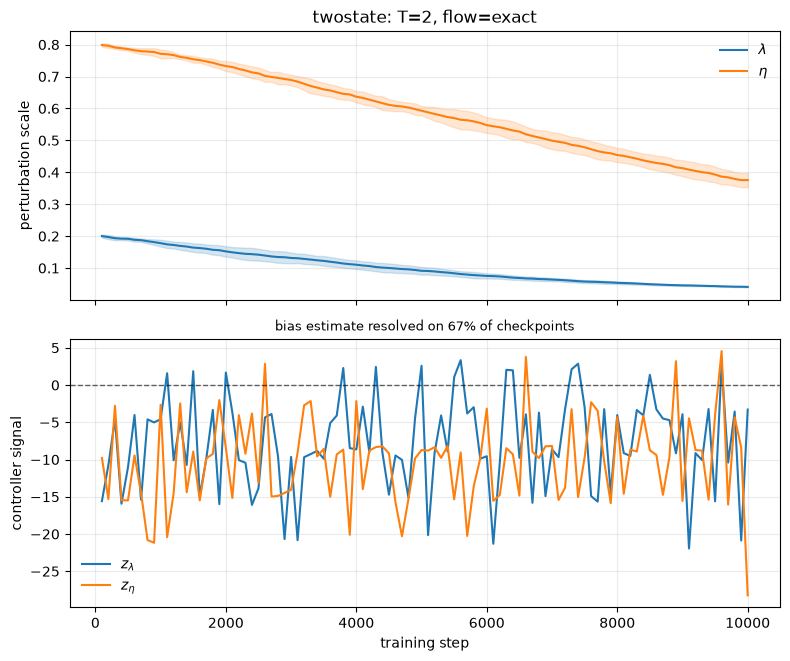

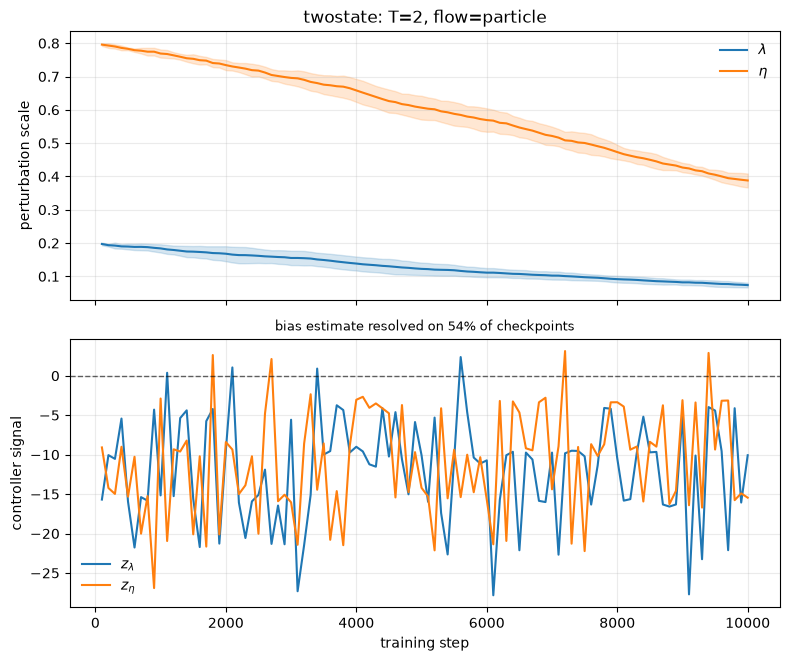

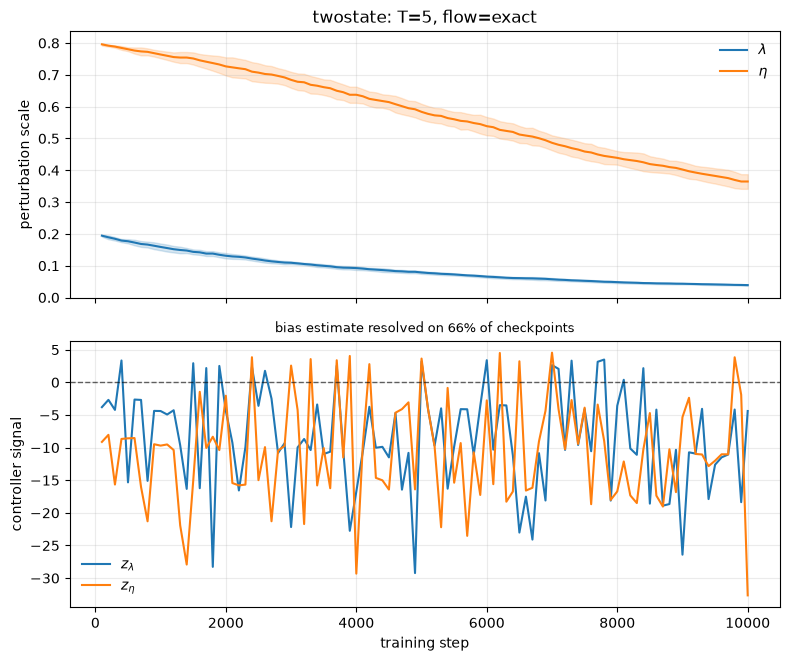

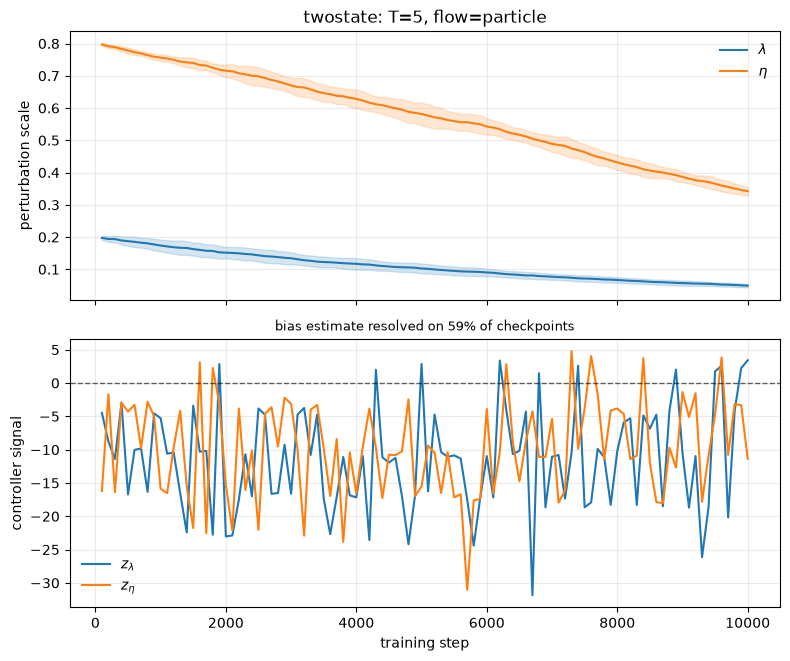

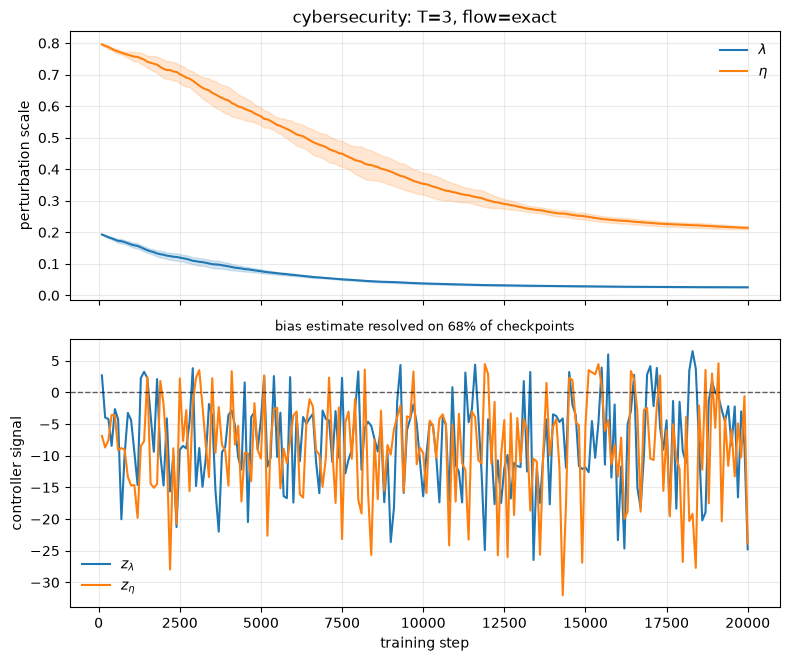

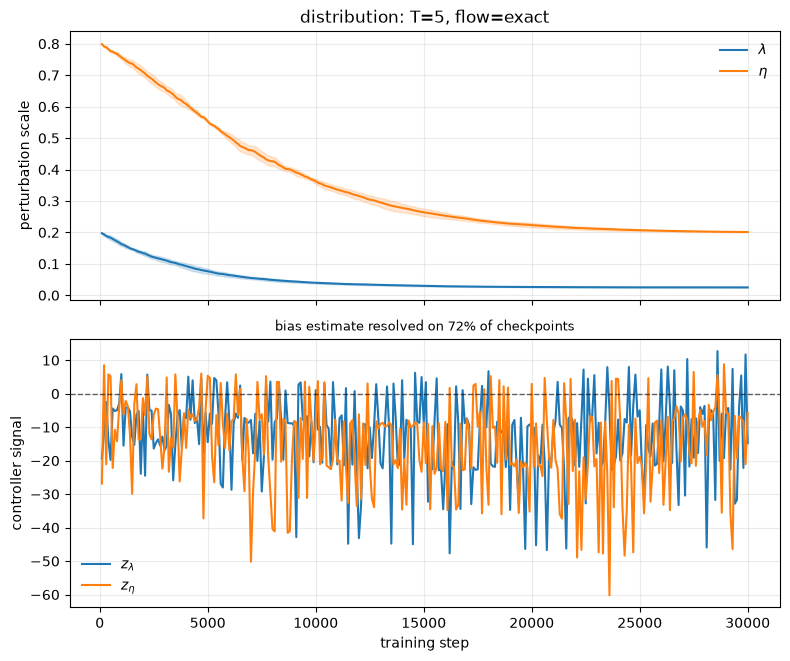

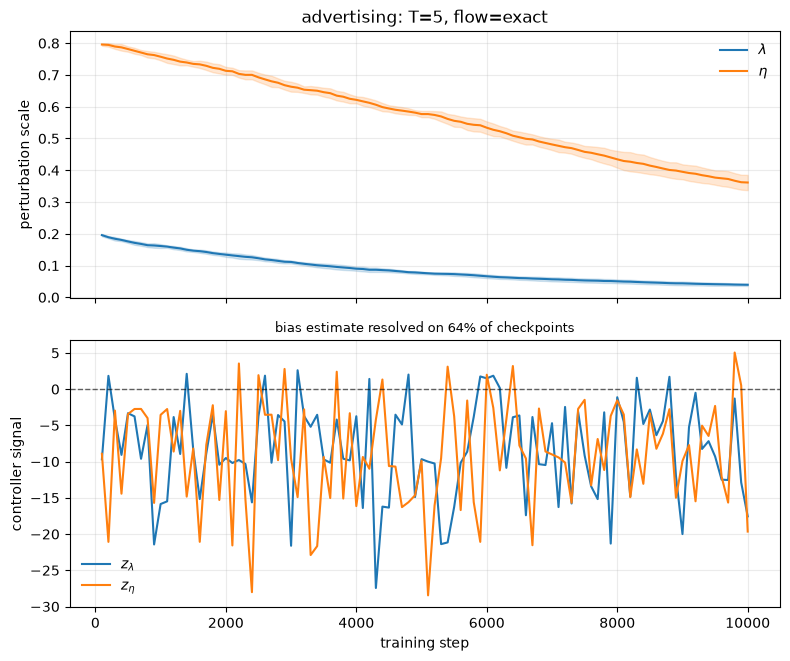

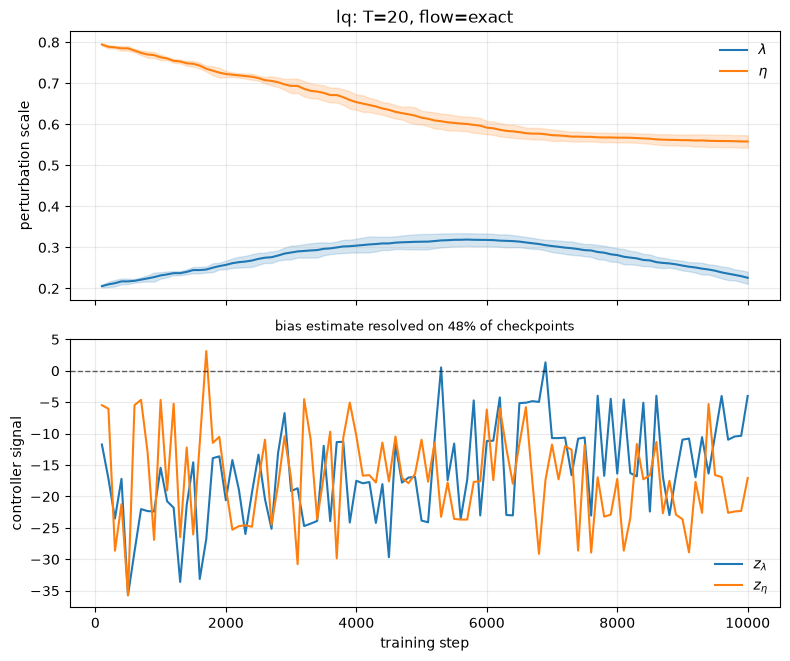

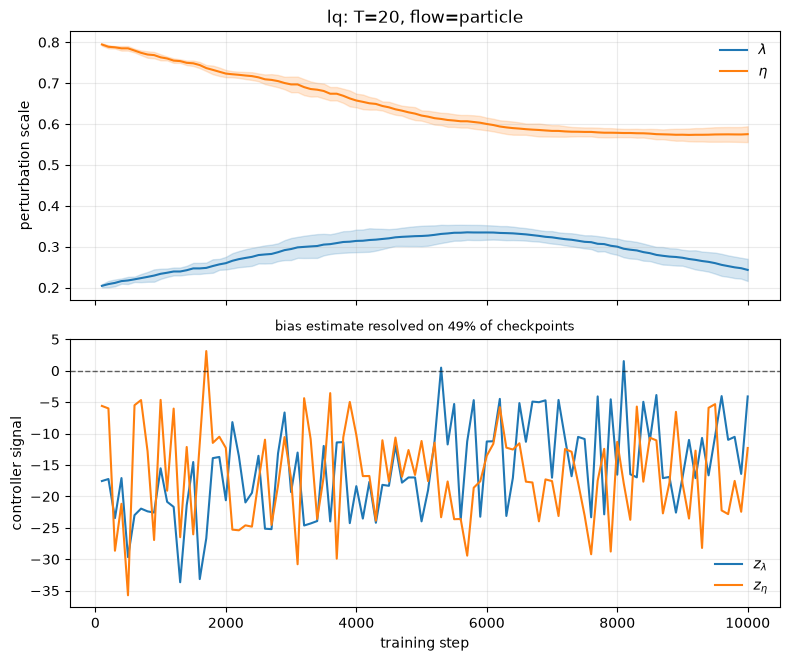

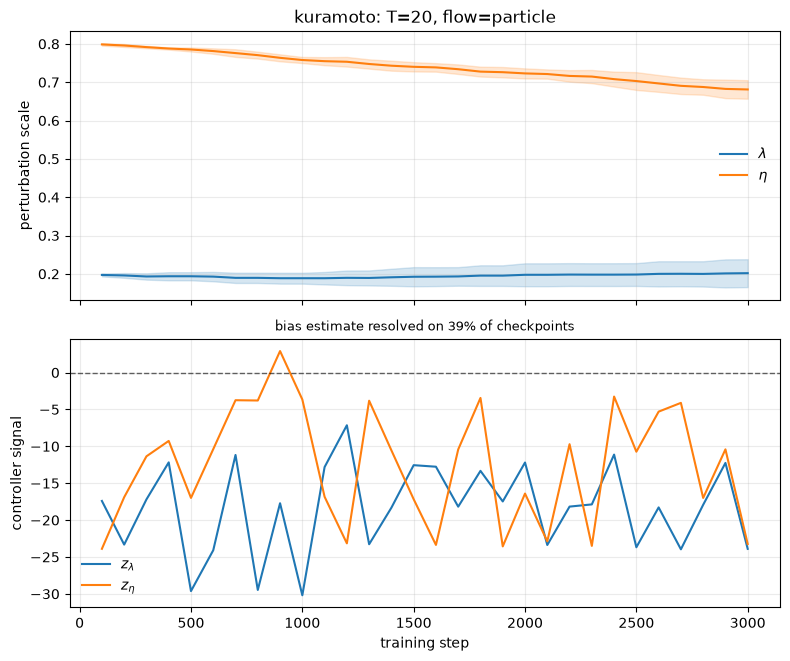

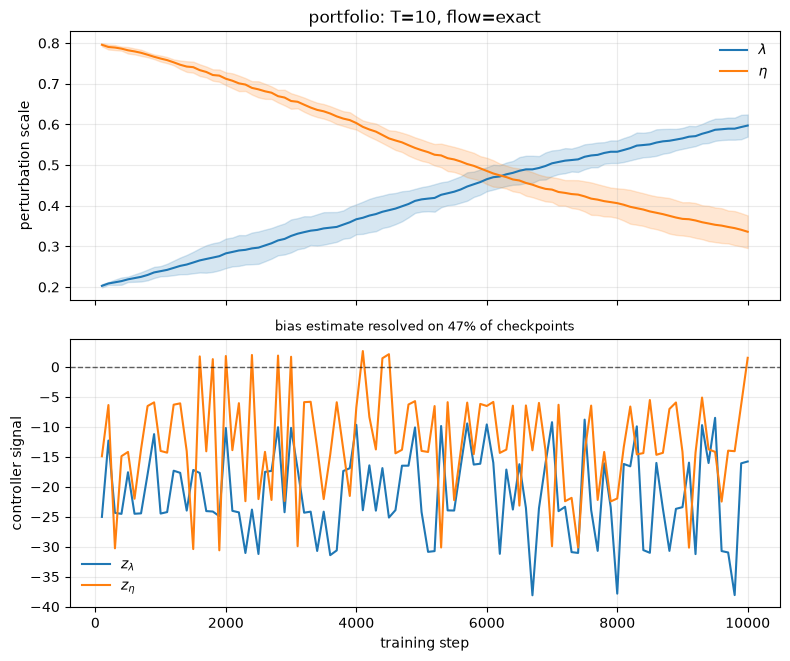

In [2]:
if not runs_by_env:
    print('No adaptive-transport runs found. Run scripts/run.py before executing the analysis cells.')

for env, env_runs in runs_by_env.items():
    schedule = adaptive_schedule_dataframe(env_runs)
    for (horizon, flow), _ in schedule.groupby(['horizon', 'flow']):
        axes = plot_adaptive_schedule(env_runs, env=env, horizon=horizon, flow=flow)
        axes[0].set_title(f'{env}: T={horizon}, flow={flow}')
        plt.show()

## Where Each Scale Ends Up

Start and end values of $\lambda$ and $\eta$, with the fraction of checkpoints on which the
controller actually moved. A scale that ends near its bound with a low resolution rate has been
driven there by unresolved bias estimates rather than by evidence.

In [3]:
rows = []
for env, env_runs in runs_by_env.items():
    schedule = adaptive_schedule_dataframe(env_runs)
    for (horizon, flow, seed), group in schedule.groupby(['horizon', 'flow', 'seed']):
        group = group.sort_values('step')
        resolved = group['lambda_resolved'].dropna()
        rows.append({
            'env': env,
            'horizon': horizon,
            'flow': flow,
            'seed': seed,
            'lambda_start': group['lambda'].iloc[0],
            'lambda_end': group['lambda'].iloc[-1],
            'eta_start': group['eta'].iloc[0],
            'eta_end': group['eta'].iloc[-1],
            'z_lambda_mean': group['z_lambda'].mean(),
            'z_eta_mean': group['z_eta'].mean(),
            'lambda_resolved_rate': float(resolved.mean()) if not resolved.empty else float('nan'),
        })

endpoints = pd.DataFrame(rows)
if endpoints.empty:
    print('No adaptive schedules available.')
else:
    display(
        endpoints.groupby(['env', 'horizon', 'flow'], as_index=False).agg(
            lambda_start=('lambda_start', 'mean'),
            lambda_end=('lambda_end', 'mean'),
            lambda_end_std=('lambda_end', 'std'),
            eta_end=('eta_end', 'mean'),
            z_lambda_mean=('z_lambda_mean', 'mean'),
            z_eta_mean=('z_eta_mean', 'mean'),
            lambda_resolved_rate=('lambda_resolved_rate', 'mean'),
            n_seeds=('seed', 'count'),
        ).round(3)
    )

,env,horizon,flow,lambda_start,lambda_end,lambda_end_std,eta_end,z_lambda_mean,z_eta_mean,lambda_resolved_rate,n_seeds
0,advertising,5,exact,0.196,0.040,0.004,0.361,-8.289,-8.906,0.644,5
1,cybersecurity,3,exact,0.193,0.026,0.000,0.214,-7.656,-8.668,0.679,5
2,distribution,5,exact,0.197,0.025,0.000,0.201,-12.206,-15.033,0.721,5
3,kuramoto,20,particle,0.197,0.202,0.036,0.681,-18.367,-12.533,0.387,5
4,lq,20,exact,0.206,0.226,0.015,0.558,-15.982,-17.013,0.476,5
5,lq,20,particle,0.204,0.243,0.027,0.575,-15.597,-16.408,0.492,5
6,portfolio,10,exact,0.203,0.597,0.027,0.336,-21.319,-12.664,0.474,5
7,twostate,2,exact,0.200,0.041,0.002,0.376,-7.683,-10.189,0.666,5
8,twostate,2,particle,0.197,0.074,0.007,0.388,-11.915,-10.899,0.542,5
9,twostate,5,exact,0.194,0.039,0.002,0.365,-8.620,-10.446,0.656,5


## Bias and Variance at the Checkpoints

The two quantities the balance signal is built from. `bias_lambda` is clamped at zero whenever
the replications cannot resolve it, so a high proportion of exact zeros indicates that the
controller is operating without a usable bias estimate.

In [4]:
rows = []
for env, env_runs in runs_by_env.items():
    schedule = adaptive_schedule_dataframe(env_runs)
    for (horizon, flow), group in schedule.groupby(['horizon', 'flow']):
        rows.append({
            'env': env,
            'horizon': horizon,
            'flow': flow,
            'bias_lambda_median': group['bias_lambda'].median(),
            'bias_eta_median': group['bias_eta'].median(),
            'variance_median': group['variance'].median(),
            'bias_lambda_zero_rate': float((group['bias_lambda'] <= 0.0).mean()),
            'bias_eta_zero_rate': float((group['bias_eta'] <= 0.0).mean()),
            'checkpoints': len(group),
        })

signals = pd.DataFrame(rows)
if signals.empty:
    print('No adaptive schedules available.')
else:
    display(signals.round(4))

,env,horizon,flow,bias_lambda_median,bias_eta_median,variance_median,bias_lambda_zero_rate,bias_eta_zero_rate,checkpoints
0,twostate,2,exact,2.036000e-01,0.0000,1.586100e+00,0.4580,0.5260,500
1,twostate,2,particle,0.000000e+00,0.0000,2.846300e+00,0.5240,0.5640,500
2,twostate,5,exact,0.000000e+00,0.0000,2.716170e+01,0.5020,0.5440,500
3,twostate,5,particle,0.000000e+00,0.0000,3.771840e+01,0.5400,0.5740,500
4,cybersecurity,3,exact,0.000000e+00,0.0000,2.776270e+01,0.5400,0.5540,1000
5,distribution,5,exact,1.116893e+07,0.0000,2.569526e+13,0.4853,0.5133,1500
6,advertising,5,exact,0.000000e+00,0.0000,4.334700e+00,0.5460,0.5840,500
7,lq,20,exact,0.000000e+00,0.0000,3.150130e+01,0.6100,0.5860,500
8,lq,20,particle,0.000000e+00,0.0000,3.528140e+01,0.6000,0.5600,500
9,kuramoto,20,particle,0.000000e+00,0.0000,3.378150e+01,0.6200,0.5933,150


## Adaptive Against the Fixed-Scale Grid

Final validation reward of adaptive transport next to the fixed-scale transport runs it is
meant to replace. The point of the controller is to reach a competitive scale without an
environment-specific grid search, so it should land near the best fixed $\lambda$ rather than
beat it.

In [5]:
for env, env_runs in runs_by_env.items():
    table = objective_table(env_runs)
    if table.empty:
        continue
    summary = table.groupby(['label', 'flow', 'horizon'], as_index=False).agg(
        validation_reward=('validation_reward', 'mean'),
        std=('validation_reward', 'std'),
    ).sort_values('validation_reward', ascending=False)
    print(f'=== {env} ===')
    display(summary.round(4))

=== twostate ===


,label,flow,horizon,validation_reward,std
39,"Transport lambda=0.1, eta=0.95",exact,5,-3.1332,0.0423
35,"Transport lambda=0.1, eta=0.85",exact,5,-3.1538,0.0419
23,"Transport lambda=0.05, eta=0.95",exact,5,-3.1976,0.0115
19,"Transport lambda=0.05, eta=0.85",exact,5,-3.2281,0.0310
1,"Adaptive transport lambda0=0.2, eta0=0.8",exact,5,-3.3960,0.1141
...,...,...,...,...,...
83,"Transport lambda=0.8, eta=0.85",exact,5,-9.8359,0.0746
89,"Transport lambda=0.8, eta=0.95",particle,5,-9.8692,0.0837
87,"Transport lambda=0.8, eta=0.95",exact,5,-9.8770,0.0716
8,REINFORCE,exact,2,-14.1179,0.0000


=== cybersecurity ===


,label,flow,horizon,validation_reward,std
2,REINFORCE,exact,3,-0.1517,0.0000
1,MF-REINFORCE eps=1,exact,3,-0.1524,0.0013
5,"Transport lambda=0.4, eta=0.85",exact,3,-0.1544,0.0030
4,"Transport lambda=0.2, eta=0.85",exact,3,-0.1552,0.0038
3,"Transport lambda=0.1, eta=0.85",exact,3,-0.1579,0.0038
0,"Adaptive transport lambda0=0.2, eta0=0.8",exact,3,-0.1602,0.0032


=== distribution ===


...

,label,flow,horizon,validation_reward,std
5,"Transport lambda=0.1, eta=0.85",exact,20,-7.2952,0.0023
6,"Transport lambda=0.1, eta=0.85",particle,20,-7.2960,0.0022
3,"Transport lambda=0.05, eta=0.85",exact,20,-7.2961,0.0021
4,"Transport lambda=0.05, eta=0.85",particle,20,-7.2968,0.0020
7,"Transport lambda=0.2, eta=0.85",exact,20,-7.2992,0.0021
8,"Transport lambda=0.2, eta=0.85",particle,20,-7.2999,0.0020
0,"Adaptive transport lambda0=0.2, eta0=0.8",exact,20,-7.3021,0.0030
1,"Adaptive transport lambda0=0.2, eta0=0.8",particle,20,-7.3045,0.0039
9,"Transport lambda=0.4, eta=0.85",exact,20,-7.3266,0.0028
10,"Transport lambda=0.4, eta=0.85",particle,20,-7.3273,0.0028


=== kuramoto ===


,label,flow,horizon,validation_reward,std
1,REINFORCE,particle,20,-1.1237,0.0012
0,"Adaptive transport lambda0=0.2, eta0=0.8",particle,20,-1.1414,0.0042
4,"Transport lambda=0.4, eta=0.85",particle,20,-1.1545,0.0205
3,"Transport lambda=0.2, eta=0.85",particle,20,-1.1646,0.0171
2,"Transport lambda=0.1, eta=0.85",particle,20,-1.1848,0.0388


=== portfolio ===


,label,flow,horizon,validation_reward,std
0,"Adaptive transport lambda0=0.2, eta0=0.8",exact,10,-17.1931,0.5937
6,"Transport lambda=0.4, eta=0.85",exact,10,-17.9802,1.0790
5,"Transport lambda=0.2, eta=0.85",exact,10,-17.9863,1.2021
4,"Transport lambda=0.1, eta=0.85",exact,10,-18.0220,1.2755
3,"Transport lambda=0.05, eta=0.85",exact,10,-18.0824,1.2904
2,"Transport lambda=0.025, eta=0.85",exact,10,-18.1947,1.2352
1,REINFORCE,exact,10,-20.5350,0.0042
